In [2]:
from utils_gene import *
import numpy as np

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Taille du fichier : 182851 octets
Graphe initial : Nodes : 198, Edges : 2742
Variance cible (SBM) : 0.05615624
------------------------------
Erreur moyenne sur les degrés (MAE) : 0.004235
Step 01 | Sigma testé: 19.1014 | Var: 0.07746053 | Δ: 2.13e-02
Erreur moyenne sur les degrés (MAE) : 0.014584
Step 02 | Sigma testé: 30.9036 | Var: 0.09057727 | Δ: 3.44e-02
Erreur moyenne sur les degrés (MAE) : 0.001189
Step 03 | Sigma testé: 11.8072 | Var: 0.06068143 | Δ: 4.53e-03
Erreur moyenne sur les degrés (MAE) : 0.000601
Step 04 | Sigma testé: 7.2992 | Var: 0.04288661 | Δ: 1.33e-02
Erreur moyenne sur les degrés (MAE) : 0.001170
Step 05 | Sigma testé: 11.7216 | Var: 0.06040735 | Δ: 4.25e-03
Erreur moyenne sur les degrés (MAE) : 0.000978
Step 06 | Sigma testé: 10.7720 | Var: 0.05720710 | Δ: 1.05e-03
Erreur moyenne sur les degrés (MAE) : 0.000779
Step 07 | Sigma testé: 9.4455 | Var: 0.05222331 | Δ: 3.93e-03
Erreur moyenne sur les degrés (MAE) : 0.000937
Step 08 | Sigma testé: 10.5382 | Var: 0.056

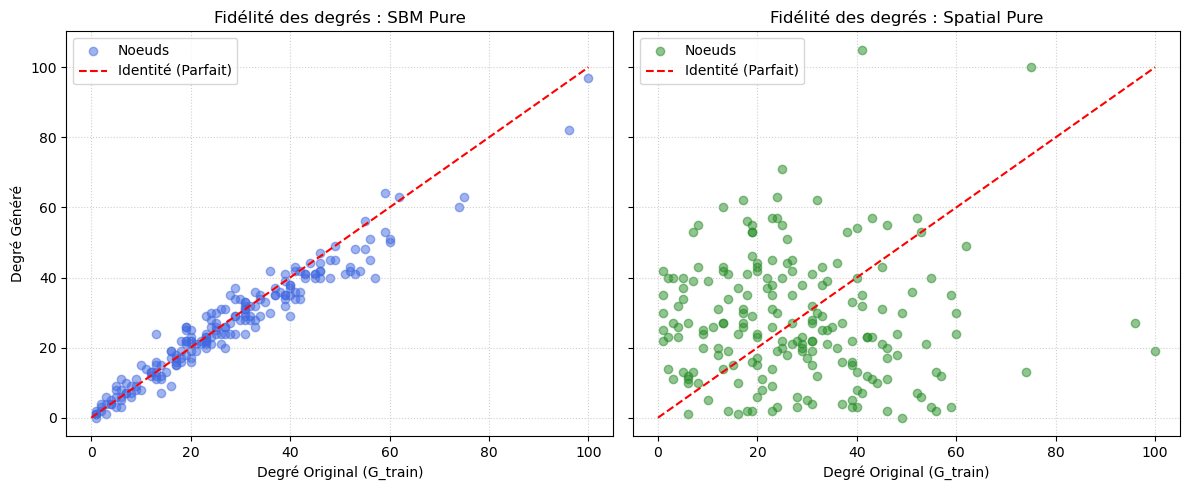

Erreur Moyenne Absolue (MAE) SBM     : 3.23
Erreur Moyenne Absolue (MAE) Spatial : 20.25
Proba moyenne pour les arêtes réelles : 0.544499
Proba min pour une arête réelle : 0.000409240821
Nombre d'arêtes 'impossibles' selon le modèle : 0
Proba moyenne pour les arêtes réelles : 0.549528
Proba min pour une arête réelle : 0.003208435747
Nombre d'arêtes 'impossibles' selon le modèle : 0


In [3]:
G_name = "reel_jazz_collab_w_attributes.joblib"
path = f"../../graph_library/{G_name}"
print(f"Taille du fichier : {os.path.getsize(path)} octets")

G = joblib.load(path)
print(f"Graphe initial : Nodes : {G.number_of_nodes()}, Edges : {G.number_of_edges()}")

e_rs, k, commus = get_real_graph_properties_sbm_V2(G)
#P_sbm = get_probs_sbm_non_DC(e_rs, commus)
P_sbm = get_probs_sbm_DC(e_rs, k , commus)

degrees, position = get_real_graph_properties_pos_V2(G)
sigma_opt, P_spatial_calibrated = match_spatial_to_sbm_variance(P_sbm, degrees, position, DC=True)
#P_spatial = get_probs_spatial_non_DC(position, n_liens_target= G.number_of_edges(), sigma = sigma_opt)
P_spatial, degrees = get_probs_spatial_DC(degrees, position, sigma = sigma_opt)

g_sbm = generate_graph_from_probs(P_sbm)
g_spatial = generate_graph_from_probs(P_spatial)
g_spatial_nx = convert_to_nx_with_metadata(g_spatial, position, k, degrees, commus, e_rs)
g_sbm_nx = convert_to_nx_with_metadata(g_sbm, position, k, degrees, commus, e_rs, P_sbm)


print(f"P_SBM : {P_sbm[2][3]}")
print(f"P_SBM : {P_sbm[3][2]}")

nu = g_spatial_nx.nodes[0]
print(f"DEBUG: Attr cherché: | Présents dans nu: {list(nu.keys())}")

print(f"SBM VS spatial = {g_sbm.num_edges()} VS {g_spatial.num_edges()}")

entropy_sbm = get_entropy_from_p(P_sbm)
log_likelyhood_sbm = get_log_likelihood(g_sbm, P_sbm)
entropy_spatial = get_entropy_from_p(P_spatial)
log_likelyhood_spatial = get_log_likelihood(g_spatial, P_spatial)
var_sbm = get_variance_from_P(P_sbm)
var_spatial = get_variance_from_P(P_spatial)

print(f" Entropy VS Log_likelyhood SBM : {entropy_sbm} / {log_likelyhood_sbm}")
print(f" Entropy VS Log_likelyhood Spatial : {entropy_spatial} / {log_likelyhood_spatial}")
print(f" Variance SBM VS Spatial : {var_sbm} / {var_spatial}")

plot_degree_correlation(k, g_sbm, g_spatial)
#visualize_generation_diagnostics_v2(P_sbm, P_spatial, k, e_rs, b)

analyze_errors(g_spatial, P_spatial)
analyze_errors(g_sbm, P_sbm)

In [10]:
Hybrid_ratios_list = np.arange(0.00, 1.10, 0.10)

all_P_matrices = generate_graph_benchmarks(Hybrid_ratios_list, P_sbm, P_spatial, position, k, degrees, commus, 
                          e_rs, name="artificial_graph_sbmv5", save_P_matrix=True)

# --- Aperçu de l'objet all_P_matrices ---
print("\n" + "="*90)
print("🔍 APERÇU DU DICTIONNAIRE DE MATRICES (all_P_matrices)")
print("="*90)
print(f"Nombre de matrices stockées : {len(all_P_matrices)}")
print(f"Ratios disponibles (clés)  : {list(all_P_matrices.keys())}")

# Print de quelques valeurs pour tester l'accès [u, v]
# On prend le premier alpha et on affiche un coin 3x3 de la matrice
first_alpha = list(all_P_matrices.keys())[0]
print(f"\nExtrait de la matrice pour alpha = {first_alpha} (nœuds 0 à 2) :")
print(all_P_matrices[first_alpha][:3, :3]) 
print("="*90)


Pour ratio_sbm = 0.0

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv5_0_00_pos_1_00.graphml

Pour ratio_sbm = 0.1

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv5_0_10_pos_0_90.graphml

Pour ratio_sbm = 0.2

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv5_0_20_pos_0_80.graphml

Pour ratio_sbm = 0.30000000000000004

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv5_0_30_pos_0_70.graphml

Pour ratio_sbm = 0.4

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv5_0_40_pos_0_60.graphml

Pour ratio_sbm = 0.5

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv5_0_50_pos_0_50.graphml

Pour ratio_sbm = 0.6000000000000001

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv5_0_60_pos_0_40.graphml

Pour ratio_sbm = 0.7000000000000001

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv5_

In [17]:
G = load_graphml_safe("../../graph_library/artificial_graph_sbmv5_1_00_pos_0_00.graphml")
plot_sbm_density_comparison(G)

Graphe chargé : 198 nœuds et 2601 liens.
Erreur : L'attribut 'GT_true_probs' est introuvable.
